# Logistic Regression Comparison: v1 vs v2 vs v3

This notebook aligns LR evaluation with the DL-style comparison setup across three prepared datasets:
- **v1**: `X_*_v1.csv`
- **v2**: `X_*_v2.csv`
- **v3**: `X_*.csv`

## Selection rule
- **Primary model selection**: highest **Validation PR-AUC** (threshold-free, stable for imbalance)
- **Threshold tuning per version**: maximize **Validation G-Mean** on ROC thresholds
- **Paper-comparable metric**: report **G-Mean** on both validation and test sets


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 200)


In [2]:
# Version configuration
VERSIONS = {
    'v1': {
        'base_dir': Path('../data/aimon-data'),
        'x_train': 'X_train_v1.csv',
        'x_val': 'X_val_v1.csv',
        'x_test': 'X_test_v1.csv',
        'y_train': 'y_train.csv',
        'y_val': 'y_val.csv',
        'y_test': 'y_test.csv',
        'already_scaled': True,
    },
    'v2': {
        'base_dir': Path('../data/aimon-data'),
        'x_train': 'X_train_v2.csv',
        'x_val': 'X_val_v2.csv',
        'x_test': 'X_test_v2.csv',
        'y_train': 'y_train.csv',
        'y_val': 'y_val.csv',
        'y_test': 'y_test.csv',
        'already_scaled': True,
    },
    'v3': {
        'base_dir': Path('../data/airam-data'),
        'x_train': 'X_train.csv',
        'x_val': 'X_val.csv',
        'x_test': 'X_test.csv',
        'y_train': 'y_train.csv',
        'y_val': 'y_val.csv',
        'y_test': 'y_test.csv',
        'already_scaled': False,  # will scale in this notebook
    },
}


In [3]:
def gmean_from_labels(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn + 1e-12)           # sensitivity / TPR
    specificity = tn / (tn + fp + 1e-12)      # TNR
    gmean = np.sqrt(recall * specificity)
    return gmean, recall, specificity, cm


def load_version_data(cfg):
    base = cfg['base_dir']
    X_train = pd.read_csv(base / cfg['x_train'])
    X_val = pd.read_csv(base / cfg['x_val'])
    X_test = pd.read_csv(base / cfg['x_test'])

    y_train = pd.read_csv(base / cfg['y_train']).squeeze()
    y_val = pd.read_csv(base / cfg['y_val']).squeeze()
    y_test = pd.read_csv(base / cfg['y_test']).squeeze()

    return X_train, X_val, X_test, y_train, y_val, y_test


def evaluate_lr_version(version_name, cfg):
    X_train, X_val, X_test, y_train, y_val, y_test = load_version_data(cfg)

    # Scale only when needed (v3)
    if not cfg['already_scaled']:
        scaler = StandardScaler()
        X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
        X_val = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
        X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    model = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)

    # Validation probabilities
    y_val_prob = model.predict_proba(X_val)[:, 1]

    # Threshold-free metrics (for model selection)
    val_roc_auc = roc_auc_score(y_val, y_val_prob)
    val_pr_auc = average_precision_score(y_val, y_val_prob)

    # G-Mean thresholding on validation ROC
    fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
    gmean_vals = np.sqrt(tpr * (1 - fpr))
    best_idx = int(np.argmax(gmean_vals))
    best_th = thresholds[best_idx]

    # Validation point metrics at G-Mean threshold
    y_val_pred = (y_val_prob >= best_th).astype(int)
    val_gmean, val_recall, val_specificity, val_cm = gmean_from_labels(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
    val_precision = precision_score(y_val, y_val_pred, zero_division=0)

    # Test metrics using selected validation threshold
    y_test_prob = model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_prob >= best_th).astype(int)

    test_roc_auc = roc_auc_score(y_test, y_test_prob)
    test_pr_auc = average_precision_score(y_test, y_test_prob)
    test_gmean, test_recall, test_specificity, test_cm = gmean_from_labels(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)

    result = {
        'version': version_name,
        'n_features': X_train.shape[1],
        'val_pr_auc': val_pr_auc,
        'val_roc_auc': val_roc_auc,
        'val_gmean': val_gmean,
        'val_f1': val_f1,
        'val_recall': val_recall,
        'val_precision': val_precision,
        'best_threshold_gmean': best_th,
        'test_pr_auc': test_pr_auc,
        'test_roc_auc': test_roc_auc,
        'test_gmean': test_gmean,
        'test_f1': test_f1,
        'test_recall': test_recall,
        'test_precision': test_precision,
        'test_specificity': test_specificity,
    }

    artifacts = {
        'model': model,
        'val_curve': (fpr, tpr, thresholds, gmean_vals),
        'val_cm': val_cm,
        'test_cm': test_cm,
        'y_test': y_test,
        'y_test_pred': y_test_pred,
    }

    return result, artifacts


In [4]:
all_results = []
all_artifacts = {}

for vname, cfg in VERSIONS.items():
    res, art = evaluate_lr_version(vname, cfg)
    all_results.append(res)
    all_artifacts[vname] = art

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('val_pr_auc', ascending=False).reset_index(drop=True)

# Best run by primary selection rule: highest validation PR-AUC
best_version = results_df.loc[0, 'version']

results_df


,version,n_features,val_pr_auc,val_roc_auc,val_gmean,val_f1,val_recall,val_precision,best_threshold_gmean,test_pr_auc,test_roc_auc,test_gmean,test_f1,test_recall,test_precision,test_specificity
0,v3,106,0.463196,0.917911,0.855606,0.310160,0.828571,0.190789,0.326567,0.508672,0.947590,0.897272,0.340426,0.909091,0.209424,0.885606
1,v1,94,0.316822,0.877564,0.841384,0.248889,0.848485,0.145833,0.331982,0.249096,0.872758,0.831651,0.229508,0.848485,0.132701,0.815152
2,v2,11,0.153023,0.709060,0.687819,0.119107,0.727273,0.064865,0.431892,0.123262,0.782675,0.734809,0.133017,0.848485,0.072165,0.636364


In [5]:
print('=== Logistic Regression Comparison (v1/v2/v3) ===')
print('Selection rule: highest Validation PR-AUC')
print(f'Best version: {best_version}')
print()

display_cols = [
    'version', 'n_features',
    'val_pr_auc', 'val_gmean', 'val_f1',
    'test_pr_auc', 'test_gmean', 'test_f1', 'test_recall',
    'best_threshold_gmean'
]

print(results_df[display_cols].to_string(index=False))


=== Logistic Regression Comparison (v1/v2/v3) ===
Selection rule: highest Validation PR-AUC
Best version: v3

version  n_features  val_pr_auc  val_gmean   val_f1  test_pr_auc  test_gmean  test_f1  test_recall  best_threshold_gmean
     v3         106    0.463196   0.855606 0.310160     0.508672    0.897272 0.340426     0.909091              0.326567
     v1          94    0.316822   0.841384 0.248889     0.249096    0.831651 0.229508     0.848485              0.331982
     v2          11    0.153023   0.687819 0.119107     0.123262    0.734809 0.133017     0.848485              0.431892


In [6]:
# Paper-comparable view (G-Mean emphasized)
paper_compare = results_df[[
    'version', 'n_features',
    'val_gmean', 'test_gmean',
    'val_pr_auc', 'test_pr_auc',
    'best_threshold_gmean'
]].copy()

paper_compare


,version,n_features,val_gmean,test_gmean,val_pr_auc,test_pr_auc,best_threshold_gmean
0,v3,106,0.855606,0.897272,0.463196,0.508672,0.326567
1,v1,94,0.841384,0.831651,0.316822,0.249096,0.331982
2,v2,11,0.687819,0.734809,0.153023,0.123262,0.431892


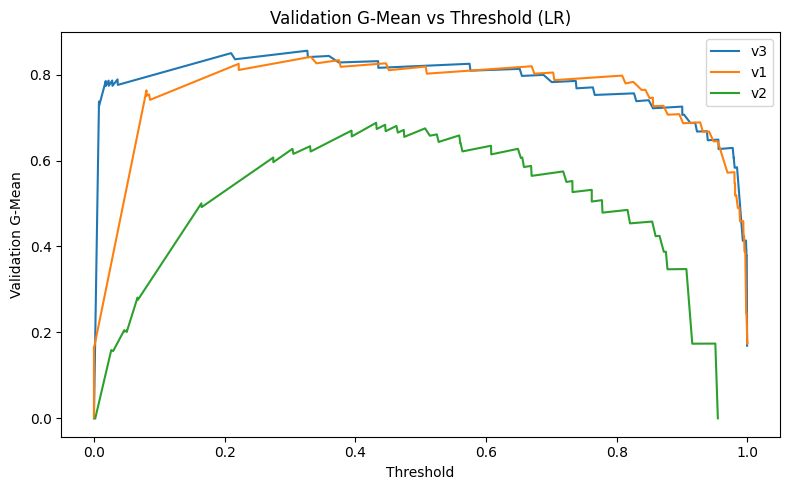

In [7]:
# Plot validation G-Mean vs threshold for each version
plt.figure(figsize=(8, 5))

for vname in results_df['version']:
    fpr, tpr, thresholds, gvals = all_artifacts[vname]['val_curve']
    # thresholds may include inf at index 0; plotting still okay
    plt.plot(thresholds, gvals, label=vname)

plt.xlabel('Threshold')
plt.ylabel('Validation G-Mean')
plt.title('Validation G-Mean vs Threshold (LR)')
plt.legend()
plt.tight_layout()
plt.show()


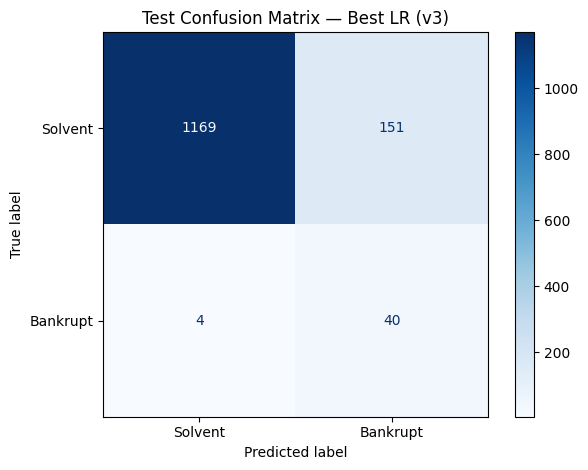

In [8]:
# Confusion matrix for selected best version
from sklearn.metrics import ConfusionMatrixDisplay

best_art = all_artifacts[best_version]
cm = best_art['test_cm']

disp = ConfusionMatrixDisplay(cm, display_labels=['Solvent', 'Bankrupt'])
disp.plot(values_format='d', cmap='Blues')
plt.title(f'Test Confusion Matrix — Best LR ({best_version})')
plt.tight_layout()
plt.show()


## Notes
- This notebook reports **G-Mean** explicitly for paper-level comparability.
- Best model is selected by **Validation PR-AUC** (threshold-free), then evaluated on test using the **validation-chosen G-Mean threshold**.
- No test-set threshold tuning is performed.
